In [1]:
# playing with transformers and non-trivial tasks: switch word location
# next should be contextual stimulus integration (then multi-input version)
# building the transformer tutorial from here:https://www.datacamp.com/tutorial/building-a-transformer-with-py-torch

import sys
sys.path.append('/Users/dhocker/projects')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import math
import copy
import numpy as np
from llm.src.model import Transformer
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2


TypeError: C function scipy.spatial._qhull._barycentric_coordinates has wrong signature (expected void (int, double *, double *, double *), got void (int, double *, double const *, double *))

In [2]:
# build your vocab and syntax
nvocab = 5000
vocab1 = np.linspace(1,nvocab,nvocab).astype(int)
vocab2 = vocab1
print(len(np.unique(vocab1)))

#syntax is that 0 and 9 start sentences.
# vocab 1 allows any ordering of words
# vocab 2 has a strict ordering: 
#. when 0 starts sentence, words should order increasing size
# when 9 starts a sentence, words should order decreasing size

# 0,1,4,2,6,8,7: v1 ---> (0, 1,2,4,6,7,8)*10 + 100 : v2
# 9,1,2,4,6,7,8: v1 ---> (9, 8,7,6,4,2,1)*10 + 100 : v2

nt = 100
ns = 64 # batch size
nstart = 10

def build_data_vocab1(vocab,nt,ns,nstart):
    """ creates a vocab  using 'words' from vocab1. size ns samples x nt time points. nstart
    number of sentences per sample"""
    np.random.seed(101)
    
    data = np.random.choice(vocab[1:-1],(ns,nt),replace=True) #omit start and end words, as they are sentence start
    # add some sentence starts. don't let it be first 2 or last two words
    starts = np.array([np.random.choice(np.linspace(2,nt-3,nt-4).astype(int),(nstart-1),replace=False) for k in range(ns)])
    # make first word be a start
    starts = np.concatenate((np.zeros((ns,1)).astype(int),starts),axis=1)

    #decide if forward or reverse translaion sentence
    start_type = np.random.choice([vocab[0],vocab[-1]],(ns,nstart),replace=True)

    for j in range(ns):
        data[j,starts[j,:]] = start_type[j,:]
        
    return data

def translate_vocab1(data,vocab):
    """ translates vocab1 in a context dependent way"""
    
    
    ns,nt = data.shape
    new_data = np.zeros((ns,nt)).astype(int)

    for j in range(ns):  

        #find starts
        idx_start = np.argwhere((data[j,:]==vocab[0]) | (data[j,:] == vocab[-1]))[:,0]
        dat_tmp_j = copy.deepcopy(data[j,:])
        for k in range(nstart-1):
            # re-order sentence in ascewnding order
            if dat_tmp_j[idx_start[k]]==vocab1[0]:
                dat_tmp_j[idx_start[k]:idx_start[k+1]] = np.sort(dat_tmp_j[idx_start[k]:idx_start[k+1]])
            else: #if sentence starts with vocab1[-1] reorder "sentence" indescending order
                test = np.sort(dat_tmp_j[idx_start[k]:idx_start[k+1]])[::-1]
                dat_tmp_j[idx_start[k]:idx_start[k+1]] = test
        new_data[j,:] = dat_tmp_j

    #finally, scale and multiply
    #new_data = new_data*10 + 1000
    
    return new_data



5000


In [3]:
data = build_data_vocab1(vocab1,nt,ns,nstart)
new_data = translate_vocab1(data,vocab1)

In [4]:
print(list(data[1,:]))
print(list(new_data[1,:]))

[1, 4563, 5000, 1280, 1, 1120, 2406, 713, 790, 2055, 2355, 5000, 2267, 2753, 4180, 5000, 1669, 2945, 4752, 3457, 563, 857, 2102, 4351, 3471, 1969, 1718, 4926, 2865, 5000, 1, 42, 4317, 4911, 611, 1946, 3638, 2117, 813, 4177, 3782, 2534, 2708, 1, 1438, 1939, 3161, 4656, 1078, 146, 4108, 192, 1900, 1017, 3196, 2537, 4761, 3544, 3652, 2616, 4803, 3771, 4690, 2138, 593, 2555, 1887, 3592, 556, 5000, 1403, 2294, 99, 2160, 4169, 3581, 1994, 210, 4831, 3950, 1514, 361, 1234, 1448, 815, 3433, 2934, 4261, 1563, 77, 2061, 3918, 1395, 2941, 3892, 2712, 5000, 2408, 4732, 1027]
[1, 4563, 5000, 1280, 1, 713, 790, 1120, 2055, 2355, 2406, 5000, 4180, 2753, 2267, 5000, 4926, 4752, 4351, 3471, 3457, 2945, 2865, 2102, 1969, 1718, 1669, 857, 563, 5000, 1, 42, 611, 813, 1946, 2117, 2534, 2708, 3638, 3782, 4177, 4317, 4911, 1, 146, 192, 556, 593, 1017, 1078, 1438, 1887, 1900, 1939, 2138, 2537, 2555, 2616, 3161, 3196, 3544, 3592, 3652, 3771, 4108, 4656, 4690, 4761, 4803, 5000, 4831, 4261, 4169, 3950, 3918, 389

In [5]:
# begin the training

src_vocab_size = nvocab+1  #a fake vocab size
tgt_vocab_size = nvocab+1
d_model = 512  #embede words into a 512-D space. whoah...
num_heads = 8  #which parts of the embedding space will be attended to?
num_layers = 6 
d_ff = 2048
max_seq_length = 100
dropout = 0.1

# Generate random sample data. 
# idea is that a word (i.e., integer) will correspond to another word. but it is random here

#src_data = torch.randint(1, src_vocab_size, (64, max_seq_length))  # (batch_size, seq_length)
#tgt_data = torch.randint(1, tgt_vocab_size, (64, max_seq_length))  # (batch_size, seq_length)
#print(tgt_data.dtype)

# my training data
#set vocab size. +1 accounts for starting at 1, rather than 0. otherwise embedding fails 
src_vocab_size = len(vocab1)+1  
tgt_vocab_size = len(vocab1)+1

#d_model = 8*10  #embede words into a 512-D space. whoah...
#num_heads = 10  #which parts of the embedding space will be attended to?
#num_layers = 6 
#d_ff = 56
#max_seq_length = 50
#dropout = 0.1


src_data = torch.tensor(data)
tgt_data = torch.tensor(new_data)

transformer = Transformer(src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout)


In [7]:
print(src_data[0,:])
#print(src_data_test[0,:])
print(torch.min(src_data))
print(torch.max(src_data))

tensor([   1, 1549, 1363,  601, 4173, 4081,  975, 2625, 3831, 4830,    1,  910,
        4575,   51, 4721, 1532, 2186, 4469, 1951, 2933, 2109, 1582, 3914, 1275,
        2325, 3980,    1,  345, 1529, 3531, 5000, 3173, 3358, 4929,  908,  438,
        3689, 3403, 3577, 1353, 2961, 4610, 3702, 4460, 2323, 4858, 2253, 1489,
        3777, 2548, 4517, 3084, 4597, 1982, 1302, 2973, 3850, 1880, 2428, 1820,
        1525, 3929, 3760, 4145, 3000, 2791, 2264, 1023, 1711, 1428, 1596, 5000,
         909,    1, 5000, 2469, 4638, 4101, 4949, 1329,    1, 2759,  634,  949,
        4058, 3440, 2121,  359, 4038, 1270,    1, 3281, 2276,    1, 1487, 4144,
        1584, 2023, 4895, 3223])
tensor(1)
tensor(5000)


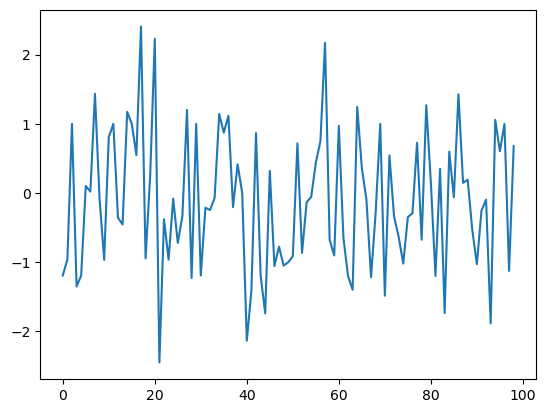

In [8]:
test = transformer.encoder_embedding(src_data[1,:-1])
plt.plot(test[:,2].detach().numpy())

In [9]:
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

transformer.train()
optimizer.zero_grad()
output = transformer(src_data, tgt_data[:, :-1])


In [120]:
output.shape

torch.Size([200, 99, 5000])

In [38]:
# do classification loss
criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(transformer.parameters(), lr=0.0001, betas=(0.9, 0.98), eps=1e-9)

transformer.train()

for epoch in range(500):
    optimizer.zero_grad()
    output = transformer(src_data, tgt_data[:, :-1])
    #todo
    loss = criterion(output.contiguous().view(-1, tgt_vocab_size), tgt_data[:, 1:].contiguous().view(-1))
    loss.backward()
    optimizer.step()
    print(f"Epoch: {epoch+1}, Loss: {loss.item()}")

Epoch: 1, Loss: 3.147840738296509
Epoch: 2, Loss: 5.3055100440979
Epoch: 3, Loss: 3.8325114250183105
Epoch: 4, Loss: 3.3687400817871094
Epoch: 5, Loss: 3.2394232749938965
Epoch: 6, Loss: 3.3032286167144775
Epoch: 7, Loss: 3.239137649536133
Epoch: 8, Loss: 3.1580677032470703
Epoch: 9, Loss: 3.0792675018310547
Epoch: 10, Loss: 3.018656015396118
Epoch: 11, Loss: 2.9782116413116455
Epoch: 12, Loss: 2.9422848224639893
Epoch: 13, Loss: 2.911151647567749
Epoch: 14, Loss: 2.8719449043273926
Epoch: 15, Loss: 2.8387300968170166
Epoch: 16, Loss: 2.7989227771759033
Epoch: 17, Loss: 2.757997751235962
Epoch: 18, Loss: 2.715822458267212
Epoch: 19, Loss: 2.680964708328247
Epoch: 20, Loss: 2.6369152069091797
Epoch: 21, Loss: 2.609217405319214
Epoch: 22, Loss: 2.5691587924957275
Epoch: 23, Loss: 2.540407419204712
Epoch: 24, Loss: 2.5103306770324707
Epoch: 25, Loss: 2.472257137298584
Epoch: 26, Loss: 2.4367363452911377
Epoch: 27, Loss: 2.4063985347747803
Epoch: 28, Loss: 2.3738231658935547
Epoch: 29, Los

Epoch: 225, Loss: 0.06966447830200195
Epoch: 226, Loss: 0.06829683482646942
Epoch: 227, Loss: 0.06855293363332748
Epoch: 228, Loss: 0.06612367928028107
Epoch: 229, Loss: 0.06596776098012924
Epoch: 230, Loss: 0.06500621140003204
Epoch: 231, Loss: 0.06461486220359802
Epoch: 232, Loss: 0.0647098496556282
Epoch: 233, Loss: 0.06242853403091431
Epoch: 234, Loss: 0.06250493973493576
Epoch: 235, Loss: 0.06127233803272247
Epoch: 236, Loss: 0.06001096963882446
Epoch: 237, Loss: 0.05886690691113472
Epoch: 238, Loss: 0.05870973691344261
Epoch: 239, Loss: 0.05829861760139465
Epoch: 240, Loss: 0.05707188695669174
Epoch: 241, Loss: 0.056769151240587234
Epoch: 242, Loss: 0.05531826987862587
Epoch: 243, Loss: 0.055476948618888855
Epoch: 244, Loss: 0.054803360253572464
Epoch: 245, Loss: 0.05329414829611778
Epoch: 246, Loss: 0.05267614871263504
Epoch: 247, Loss: 0.05151838809251785
Epoch: 248, Loss: 0.05175555869936943
Epoch: 249, Loss: 0.05113671347498894
Epoch: 250, Loss: 0.05008193105459213
Epoch: 251

Epoch: 438, Loss: 0.009373174980282784
Epoch: 439, Loss: 0.00931481085717678
Epoch: 440, Loss: 0.008496555499732494
Epoch: 441, Loss: 0.009046695195138454
Epoch: 442, Loss: 0.00882123876363039
Epoch: 443, Loss: 0.00894956011325121
Epoch: 444, Loss: 0.008499964140355587
Epoch: 445, Loss: 0.00922092143446207
Epoch: 446, Loss: 0.008515720255672932
Epoch: 447, Loss: 0.009344041347503662
Epoch: 448, Loss: 0.008346350863575935
Epoch: 449, Loss: 0.008562592789530754
Epoch: 450, Loss: 0.008039330132305622
Epoch: 451, Loss: 0.008192814886569977
Epoch: 452, Loss: 0.008498267270624638
Epoch: 453, Loss: 0.00742829404771328
Epoch: 454, Loss: 0.007990067824721336
Epoch: 455, Loss: 0.00805180985480547
Epoch: 456, Loss: 0.007697829511016607
Epoch: 457, Loss: 0.008317545987665653
Epoch: 458, Loss: 0.008006361313164234
Epoch: 459, Loss: 0.00836675800383091
Epoch: 460, Loss: 0.00894223153591156
Epoch: 461, Loss: 0.007311410270631313
Epoch: 462, Loss: 0.008132162503898144
Epoch: 463, Loss: 0.0083388490602

In [10]:
# can this captue any structure? the targts are iid random compared to inputs
savepath = '/Users/dhocker/projects/llm/results/'
#torch.save(transformer.state_dict(), savepath+'transformer_20260113.model')

transformer.load_state_dict(torch.load(savepath+'transformer_20260113.model', weights_only=True))

<All keys matched successfully>

In [12]:
#grab parts of the forward for the transformer

# get sample data
src = src_data[:,:]
tgt = tgt_data[:, :]

src_mask, tgt_mask = transformer.generate_mask(src, tgt)
src_embedded = transformer.dropout(transformer.positional_encoding(transformer.encoder_embedding(src)))
tgt_embedded = transformer.dropout(transformer.positional_encoding(transformer.decoder_embedding(tgt)))

attn = []
for enc_layer in transformer.encoder_layers:
    attn_k = enc_layer.self_attn(src_embedded, src_embedded, src_embedded, src_mask)
    attn.append(attn_k)



In [13]:
attn[0].shape

torch.Size([64, 100, 512])

In [57]:
#manually look at the attention probs
a1 = transformer.encoder_layers[4].self_attn


Q = a1.split_heads(a1.W_q(src_embedded))

K = a1.split_heads(a1.W_k(src_embedded))
V = a1.split_heads(a1.W_v(src_embedded))
print(Q.shape)

# Perform scaled dot-product attention
attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(a1.d_k)
if src_mask is not None:
    attn_scores = attn_scores.masked_fill(src_mask == 0, -1e9)
attn_probs = torch.softmax(attn_scores, dim=-1)
attn_probs.shape


torch.Size([64, 8, 100, 64])


torch.Size([64, 8, 100, 100])

In [58]:
# let's visualize a data stream
print(src[0,:])

tensor([   1, 1549, 1363,  601, 4173, 4081,  975, 2625, 3831, 4830,    1,  910,
        4575,   51, 4721, 1532, 2186, 4469, 1951, 2933, 2109, 1582, 3914, 1275,
        2325, 3980,    1,  345, 1529, 3531, 5000, 3173, 3358, 4929,  908,  438,
        3689, 3403, 3577, 1353, 2961, 4610, 3702, 4460, 2323, 4858, 2253, 1489,
        3777, 2548, 4517, 3084, 4597, 1982, 1302, 2973, 3850, 1880, 2428, 1820,
        1525, 3929, 3760, 4145, 3000, 2791, 2264, 1023, 1711, 1428, 1596, 5000,
         909,    1, 5000, 2469, 4638, 4101, 4949, 1329,    1, 2759,  634,  949,
        4058, 3440, 2121,  359, 4038, 1270,    1, 3281, 2276,    1, 1487, 4144,
        1584, 2023, 4895, 3223])


(100,)


Text(0.5, 1.0, 'attention ')

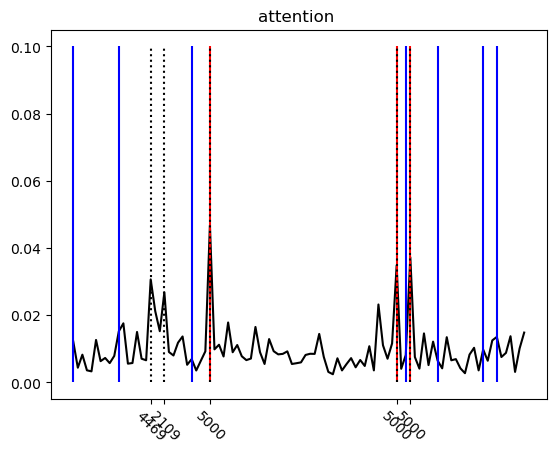

In [59]:
# look to see how each attention layer "notices" sentence starts
head_idx = 0
batch_idx = 0
#print(attn_probs[0,head_idx,0,:])
t_idx = 1

X = attn_probs[batch_idx,head_idx,t_idx,:].detach().numpy()

plt.plot(X,color='k')
x = np.argwhere(src[0,:].detach().numpy()==1)[:,0]
y = np.argwhere(src[0,:].detach().numpy()==vocab1[-1])[:,0]
[plt.vlines(k,0,0.1,color='blue') for k in x]
[plt.vlines(k,0,0.1,color='red') for k in y]

# find top 5 largest values
I = np.argsort(X)[::-1]
labels = [str(src[0,I[k]].detach().numpy()) for k in range(5)]
print(I.shape)
[plt.vlines(I[k],0,0.1,color='black',linestyle = 'dotted') for k in range(5)]
plt.xticks(I[:5],labels=labels,rotation=-45)

plt.title('attention ')


In [19]:
#what is the scaled dot product attention


tensor(0.0112, grad_fn=<SelectBackward0>)

In [67]:
#run the network and see what it gives

#output = transformer(src_data, tgt_data[:, :-1])
print(src[0,:])
print(tgt[0,:])

preds = np.argmax(output[0,:,:].detach().numpy(),axis=-1)
print(preds)



tensor([   1, 1549, 1363,  601, 4173, 4081,  975, 2625, 3831, 4830,    1,  910,
        4575,   51, 4721, 1532, 2186, 4469, 1951, 2933, 2109, 1582, 3914, 1275,
        2325, 3980,    1,  345, 1529, 3531, 5000, 3173, 3358, 4929,  908,  438,
        3689, 3403, 3577, 1353, 2961, 4610, 3702, 4460, 2323, 4858, 2253, 1489,
        3777, 2548, 4517, 3084, 4597, 1982, 1302, 2973, 3850, 1880, 2428, 1820,
        1525, 3929, 3760, 4145, 3000, 2791, 2264, 1023, 1711, 1428, 1596, 5000,
         909,    1, 5000, 2469, 4638, 4101, 4949, 1329,    1, 2759,  634,  949,
        4058, 3440, 2121,  359, 4038, 1270,    1, 3281, 2276,    1, 1487, 4144,
        1584, 2023, 4895, 3223])
tensor([   1,  601,  975, 1363, 1549, 2625, 3831, 4081, 4173, 4830,    1,   51,
         910, 1275, 1532, 1582, 1951, 2109, 2186, 2325, 2933, 3914, 3980, 4469,
        4575, 4721,    1,  345, 1529, 3531, 5000, 4929, 4858, 4610, 4597, 4517,
        4460, 4145, 3929, 3850, 3777, 3760, 3702, 3689, 3577, 3403, 3358, 3173,
       

In [64]:
test = np.argmax(output[0,:,:].detach().numpy(),axis=-1)

In [67]:
print(test)

[ 601  975 1363 1549 2625 3831 4081 4173 4830    1   51  910 1275 1532
 1582 1951 2109 2186 2325 2933 3914 3980 4469 4575 4721    1  345 1529
 3531 5000 4929 4858 4610 4597 4517 4460 4145 3929 3850 3777 3760 3702
 3689 3577 3403 3358 3173 3084 3000 2973 2961 2791 2548 2428 2323 2264
 2253 1982 1880 1820 1711 1596 1525 1489 1428 1353 1302 1023  908  438
 5000  909    1 5000 4949 4638 4101 2469 1329    1  359  634  949 1270
 2121 2759 3440 4038 4058    1 2276 3281    1 1487 4144 1584 2023 4895
 3223]


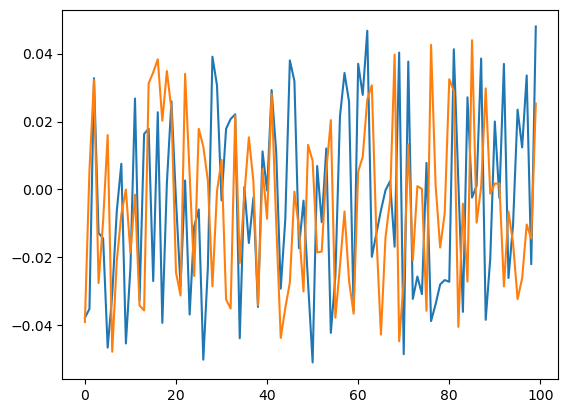

In [83]:
# what do the attention weights look like
a1 = transformer.encoder_layers[0].self_attn
plt.plot(a1.W_q.weight.detach().numpy()[0,0:100])

a1 = transformer.encoder_layers[0].self_attn
plt.plot(a1.W_v.weight.detach().numpy()[0,0:100])
plt.show()

In [74]:
test = torch.nn.Linear(3,3)

In [75]:
test.weight

Parameter containing:
tensor([[-0.1177,  0.5599,  0.2209],
        [ 0.3254, -0.0229, -0.0115],
        [ 0.5439,  0.3586, -0.0265]], requires_grad=True)